In [1]:

# import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
import pandas as pd
# import numpy as np
import random
import torch
import pickle
from tqdm import tqdm
from torch import optim
# import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from umap import UMAP
import plotly.express as px


import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score, silhouette_score


import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import cupy as cp
# from cuml.cluster import DBSCAN as cuDBSCAN
from sklearn.metrics import accuracy_score, f1_score


from deepview.calculate_results.data.umineko.umineko_data import (
    read_umineko_path,
    extract_data_from_year_back,
    label_dict,
)

from deepview.calculate_results.models.utils import (
    sliding_window,
    data_loader_umineko,
    MSEloss_weighted,
    MSEloss,
    NTXentloss,
    # torch,
    AE_eval_time_series,
    AE_train_time_series_resnet,
    # np,
    # tqdm
    Autoencoder3d4,  # debug purpose
    Autoencoder4d,
    CrossModelAutoencoderContrastiveModel,
    Autoencoder1d,
    plot_reconstruction_result,
    majority_value,
)


In [2]:
def read_sensor_data():
    raw_data, labeled_data = [], []
    for year in ['2018', '2022']:
        dp = r'D:\code\DeepView\deepview\calculate_results\data\umineko_%s.npy'
        data = np.load(dp % year, allow_pickle=True).item()
        # Access the individual components
        raw_ = data['raw_data']
        labeled_ = data['labeled_data']
        if year == '2018':
            df_raw_2018 = raw_
            df_2018 = labeled_
        # elif year=='2019':
        #     df_raw_2019 = raw_
        #     df_2019 = labeled_
        elif year == '2022':
            df_raw_2022 = raw_
            df_2022 = labeled_
        else:
            print('Error: year not found')
            break

    selected_df = pd.concat([df_raw_2018, df_raw_2022], ignore_index=True)
    selected_df['filename'] = selected_df['year'].astype(int).astype(str) + '_' + selected_df['animal_tag']
    animal_tag_list = ['2018_LB07', '2018_LB08', '2018_LB09', '2018_LB10', '2018_LB11', '2018_LB12', '2018_LB13',
                       '2022_LB02', '2022_LB03', '2022_LB08', '2022_LB09']
    selected_df = selected_df[selected_df['filename'].isin(animal_tag_list)]

    selected_df['label_id'] = selected_df['label'].map(label_dict)
    selected_df['label_id'] = selected_df['label_id'].fillna(-2)

    # # 删除无标签的数据
    # selected_df = selected_df[selected_df.label_id != -2]
    return selected_df


In [3]:
all_df = read_sensor_data()
selected_df = all_df[all_df.label_id != -2]

In [4]:
selected_df['label_id'].value_counts()

label_id
3.0    216975
0.0     57606
4.0     39625
1.0     32928
2.0     24365
5.0       430
Name: count, dtype: int64

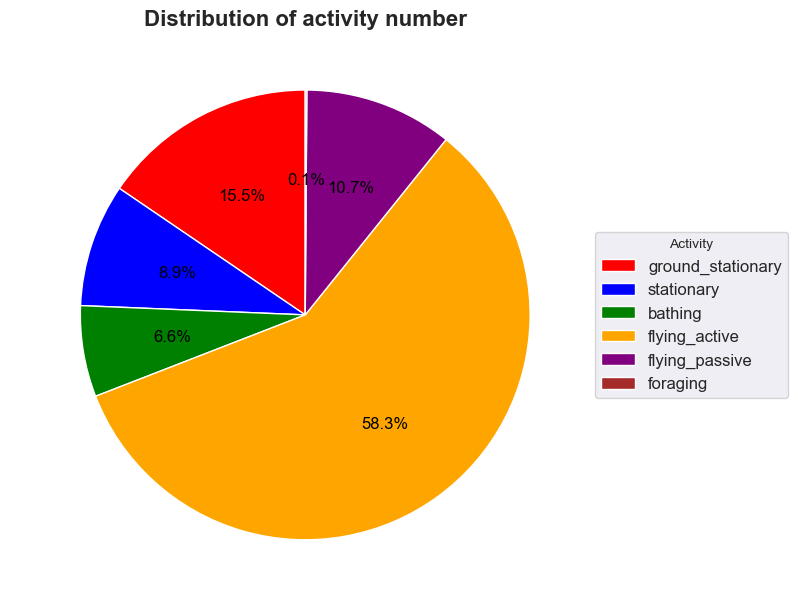

In [10]:
# 假设这些是每个 label 的数量
labels = ['ground_stationary', 'stationary', 'bathing', 'flying_active', 'flying_passive', 'foraging']
sizes = [57606,32928, 24365, 216975,39625,430]  # 对应每个 label 的数量
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']  # 选择合适的颜色

# 绘制饼图
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, 
                                    textprops=dict(color="w"), wedgeprops=dict(edgecolor='w'))

# 调整标签和比例的字体大小
for text in autotexts:
    text.set_fontsize(12)
    text.set_color('black')  # 设置比例文字颜色为黑色

# 设置图形标题
plt.title('Distribution of activity number', fontsize=16, fontweight='bold')

# 添加图例
plt.legend(wedges, labels, title="Activity", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

# 调整图形布局
plt.tight_layout()

# 保存为PDF或其他矢量图格式
plt.savefig('class_distribution_pie_chart.pdf', format='pdf', bbox_inches='tight')

# 显示图形
plt.show()

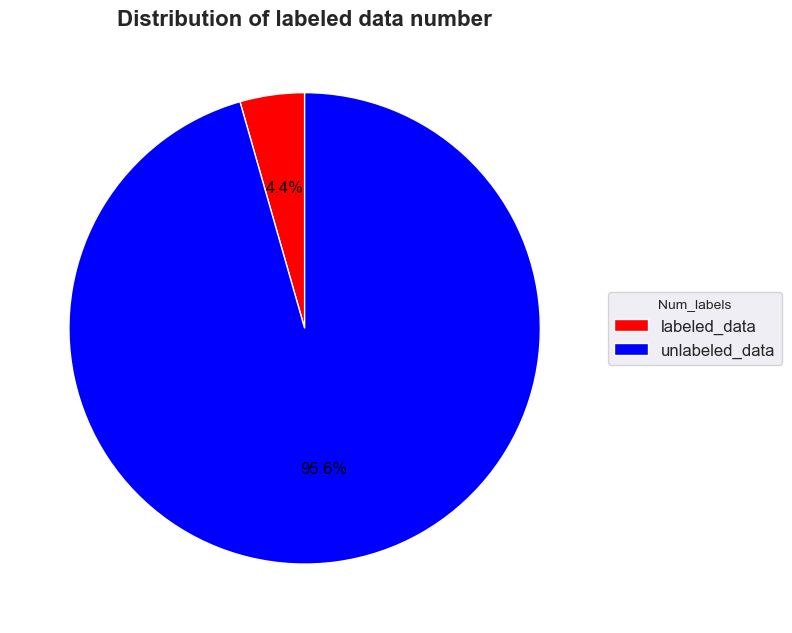

In [11]:
# 假设这些是每个 label 的数量
labels = ['labeled_data', 'unlabeled_data']
a = len(all_df)
l = len(selected_df)
sizes = [l, a-l]  # 对应每个 label 的数量
colors = ['red', 'blue']  # 选择合适的颜色

# 绘制饼图
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, 
                                    textprops=dict(color="w"), wedgeprops=dict(edgecolor='w'))

# 调整标签和比例的字体大小
for text in autotexts:
    text.set_fontsize(12)
    text.set_color('black')  # 设置比例文字颜色为黑色

# 设置图形标题
plt.title('Distribution of labeled data number', fontsize=16, fontweight='bold')

# 添加图例
plt.legend(wedges, labels, title="Num_labels", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

# 调整图形布局
plt.tight_layout()

# 保存为PDF或其他矢量图格式
plt.savefig('label_distribution_pie_chart.pdf', format='pdf', bbox_inches='tight')

# 显示图形
plt.show()